In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_cpi=pd.read_csv(r"D:\github\AAE625_2026\cpi_annual.csv")
df_income= pd.read_csv(r"D:\github\AAE625_2026\MEHOINUSA646N.csv")
print(df_cpi.head())
print(df_income.head())

  observation_date  CPIAUCSL  Unnamed: 2
0           1/1/47    22.332         NaN
1           1/1/48    24.045         NaN
2           1/1/49    23.809         NaN
3           1/1/50    24.063         NaN
4           1/1/51    25.973         NaN
  observation_date  MEHOINUSA646N
0       1984-01-01          22420
1       1985-01-01          23620
2       1986-01-01          24900
3       1987-01-01          26060
4       1988-01-01          27230


In [5]:
df_cpi = df_cpi.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "CPI"
})
df_income = df_income.rename(columns={
    "observation_date": "date",
    "MEHOINUSA646N": "Nominal_Income"
})

In [9]:
df_cpi["date"] = pd.to_datetime(df_cpi["date"])
df_income["date"] = pd.to_datetime(df_income["date"])

In [10]:
df_merged = pd.merge(df_income, df_cpi, on='date', how='inner').sort_values('date').reset_index(drop=True)

In [12]:
base_cpi = df_merged['CPI'].iloc[0] 
df_merged['Price_Index'] = df_merged['CPI'] / base_cpi
df_merged['Real_Income'] = df_merged['Nominal_Income'] / df_merged['Price_Index']


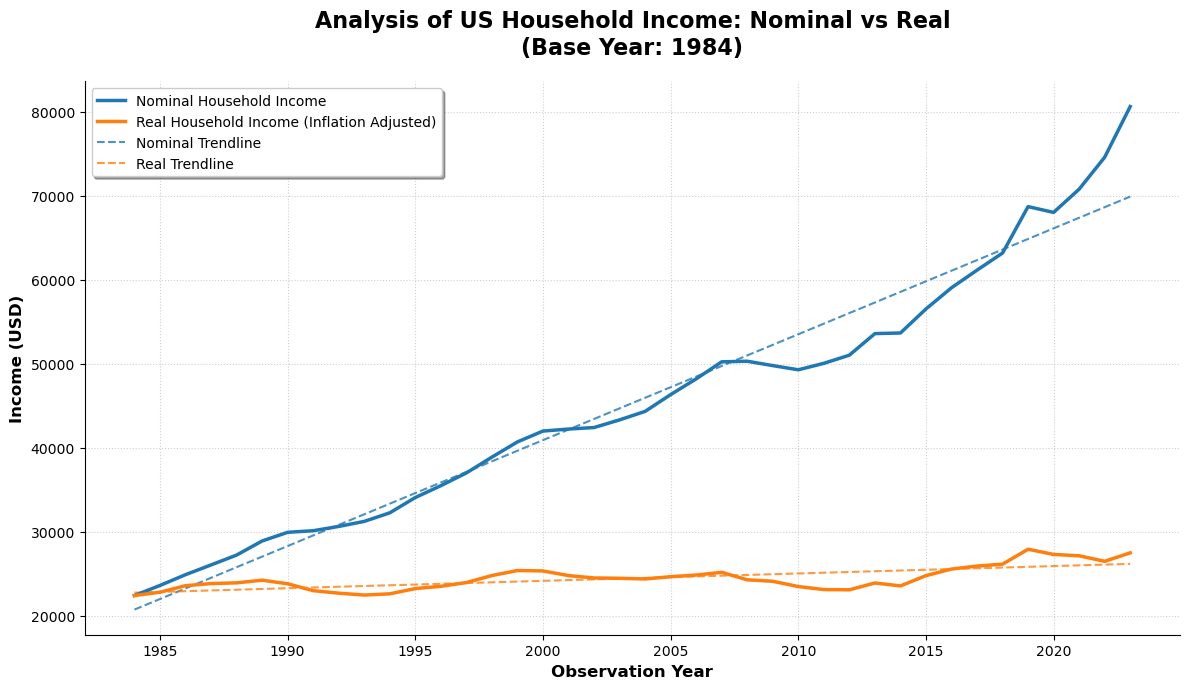

In [15]:
plt.style.use('seaborn-v0_8-muted') 
fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

x = df_merged['date']
y1 = df_merged['Nominal_Income']
y2 = df_merged['Real_Income']
x_numeric = np.arange(len(x)) 

ax.plot(x, y1, label='Nominal Household Income', color='#1f77b4', linewidth=2.5, zorder=3)
ax.plot(x, y2, label='Real Household Income (Inflation Adjusted)', color='#ff7f0e', linewidth=2.5, zorder=3)

z1 = np.polyfit(x_numeric, y1, 1)
p1 = np.poly1d(z1)
ax.plot(x, p1(x_numeric), color='#1f77b4', linestyle='--', alpha=0.8, label='Nominal Trendline', zorder=2)

z2 = np.polyfit(x_numeric, y2, 1)
p2 = np.poly1d(z2)
ax.plot(x, p2(x_numeric), color='#ff7f0e', linestyle='--', alpha=0.8, label='Real Trendline', zorder=2)


base_year = x.iloc[0].year
ax.set_title(f'Analysis of US Household Income: Nominal vs Real\n(Base Year: {base_year})', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Observation Year', fontsize=12, fontweight='semibold')
ax.set_ylabel('Income (USD)', fontsize=12, fontweight='semibold')

ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)

ax.grid(True, linestyle=':', alpha=0.6)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()